# Cell Phone Price Range Prediction

***Predicting the price range of a mobile phone based on its specifications***

## Domain: Consumer Electronics / Mobile Market

Bob has started his own mobile company and wants to compete with brands like Apple and Samsung. To price his devices competitively, he needs to predict the price range of a mobile phone based on its technical specifications.

## Problem Statement:
We aim to build a machine learning model to predict the **price range** (0: Low, 1: Medium, 2: High, 3: Very High) of a mobile phone using its features like battery power, RAM, pixel resolution, etc.


## Dataset Information

- **Total Records:** 2000  
- **Type:** Classification Dataset  
- **Target Variable:** `price_range` (4 classes)  
- **Features:** 20 (Battery Power, RAM, Bluetooth, Internal Memory, Pixel Resolution, etc.)

## Project Objectives

- **Task 1:** Perform detailed exploratory data analysis (EDA).
- **Task 2:** Build and evaluate multiple classification models to predict the price range.
- **Task 3:** Provide business recommendations based on feature importance and model insights.


## Exploratory Data Analysis (EDA)
We start with the EDA to understand the target distribution and feature correlations.

In [7]:
# Importing required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Load dataset
data = pd.read_csv("Cellphone Dataset.csv")

# Basic info
print("Dataset Shape:", data.shape)
print("\nMissing Values:\n", data.isnull().sum())
data.head()

Dataset Shape: (2000, 21)

Missing Values:
 battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64


,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


#### The dataset does not contain any missing values.  

### Target Variable Distribution
Let's check if the dataset is balanced across the 4 price ranges.

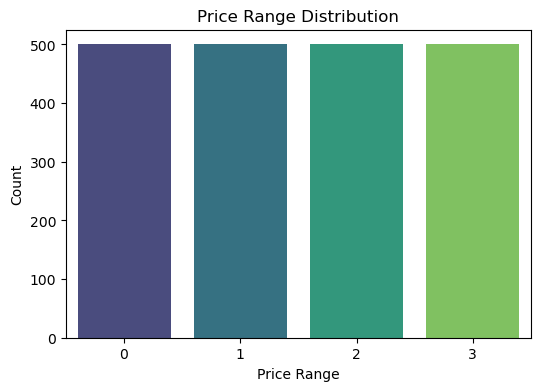

In [10]:
plt.figure(figsize=(6,4))
sns.countplot(x='price_range', data=data, palette='viridis')
plt.title('Price Range Distribution')
plt.xlabel('Price Range')
plt.ylabel('Count')
plt.show()

The target variable `price_range` is well-balanced across all four categories. No resampling techniques are required.

### Correlation Analysis
Now, let's analyze how each feature correlates with the target variable (`price_range`).

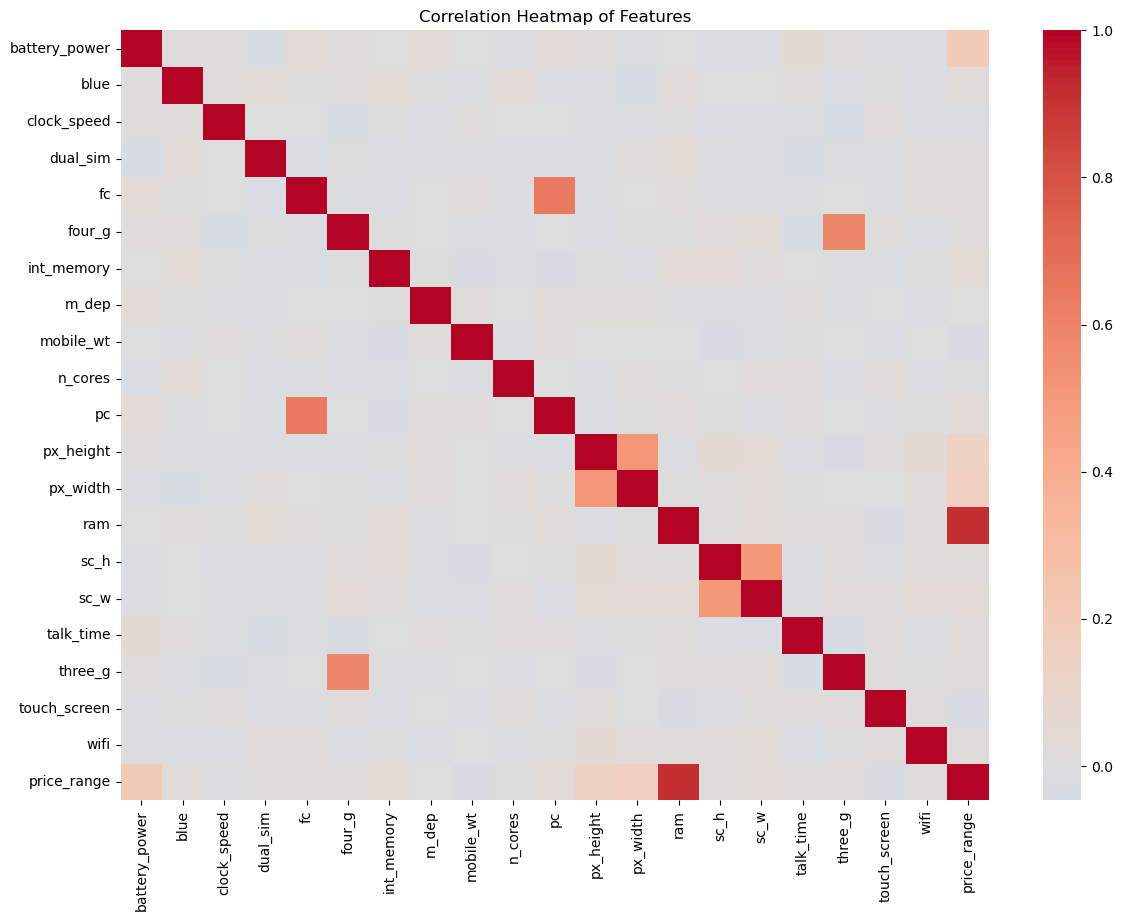

price_range      1.000000
ram              0.917046
battery_power    0.200723
px_width         0.165818
px_height        0.148858
int_memory       0.044435
sc_w             0.038711
pc               0.033599
three_g          0.023611
sc_h             0.022986
fc               0.021998
talk_time        0.021859
blue             0.020573
wifi             0.018785
dual_sim         0.017444
four_g           0.014772
n_cores          0.004399
m_dep            0.000853
clock_speed     -0.006606
mobile_wt       -0.030302
touch_screen    -0.030411
Name: price_range, dtype: float64

In [13]:
# Correlation heatmap
plt.figure(figsize=(14,10))
corr = data.corr()
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap of Features')
plt.show()

# Correlation with price range
corr_target = corr['price_range'].sort_values(ascending=False)
corr_target

### Observations:
- **RAM (0.917)** is the most significant feature.
- **Battery Power, Pixel Width, and Pixel Height** also show moderate positive correlation.
- Other features like `clock_speed`, `mobile_wt`, `dual_sim` have very weak correlation individually but may still be useful in non-linear models.

## Feature vs Price Range Analysis
Let's visualize how the top features (RAM, Battery Power, Pixel Width, Pixel Height) vary across price ranges.

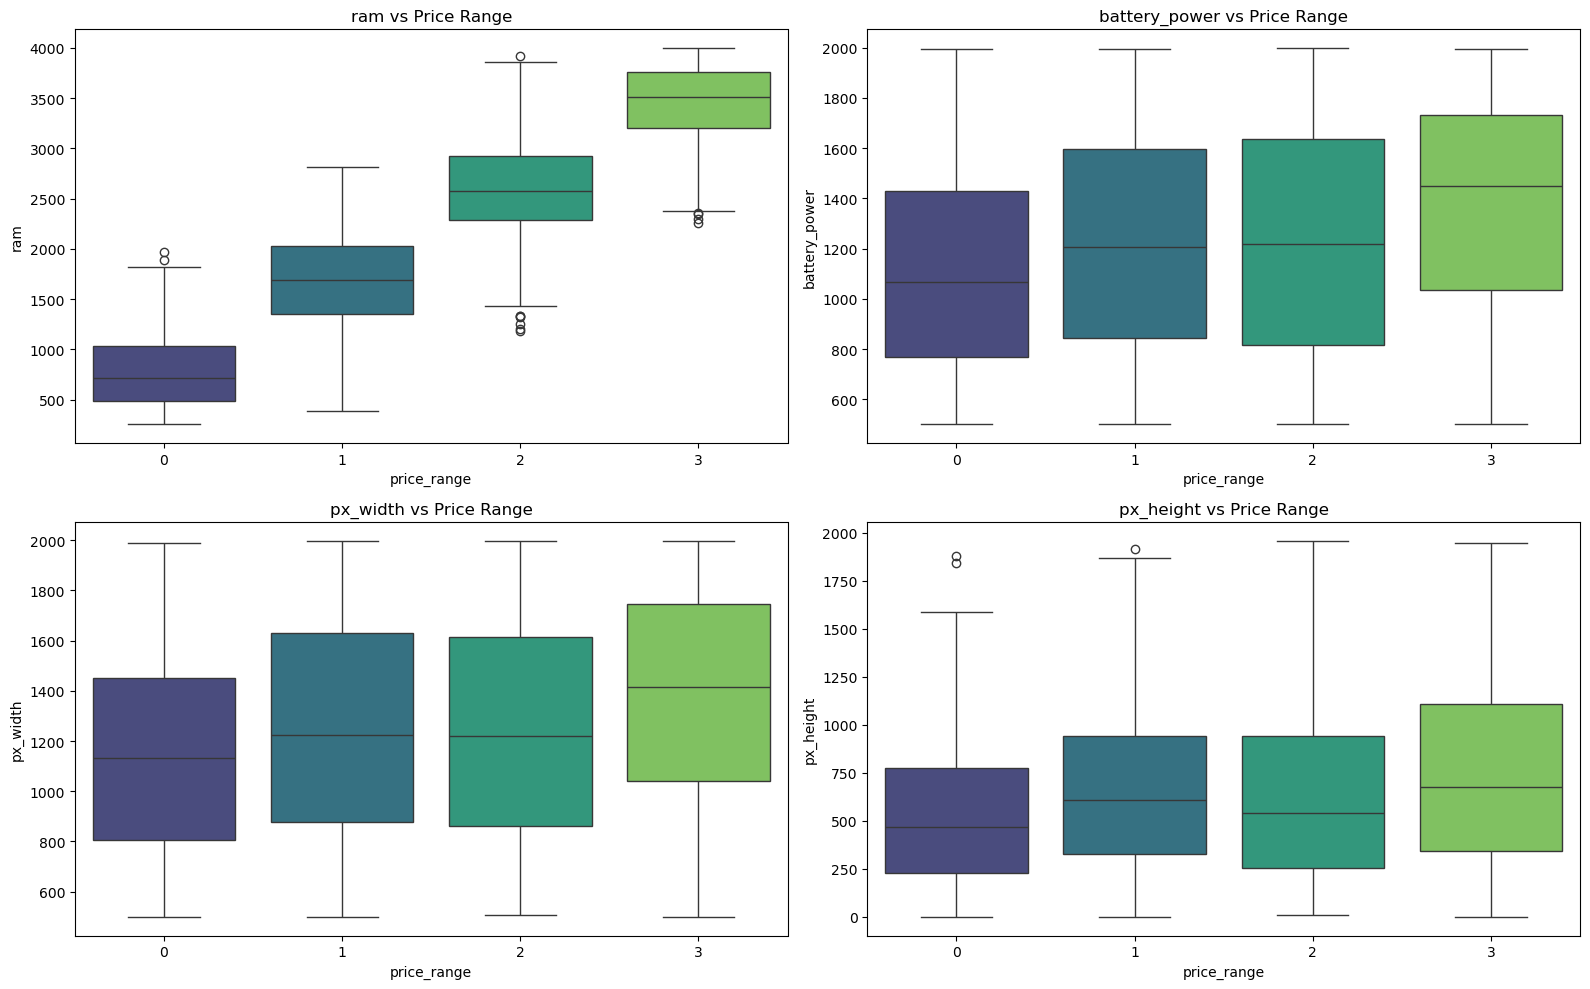

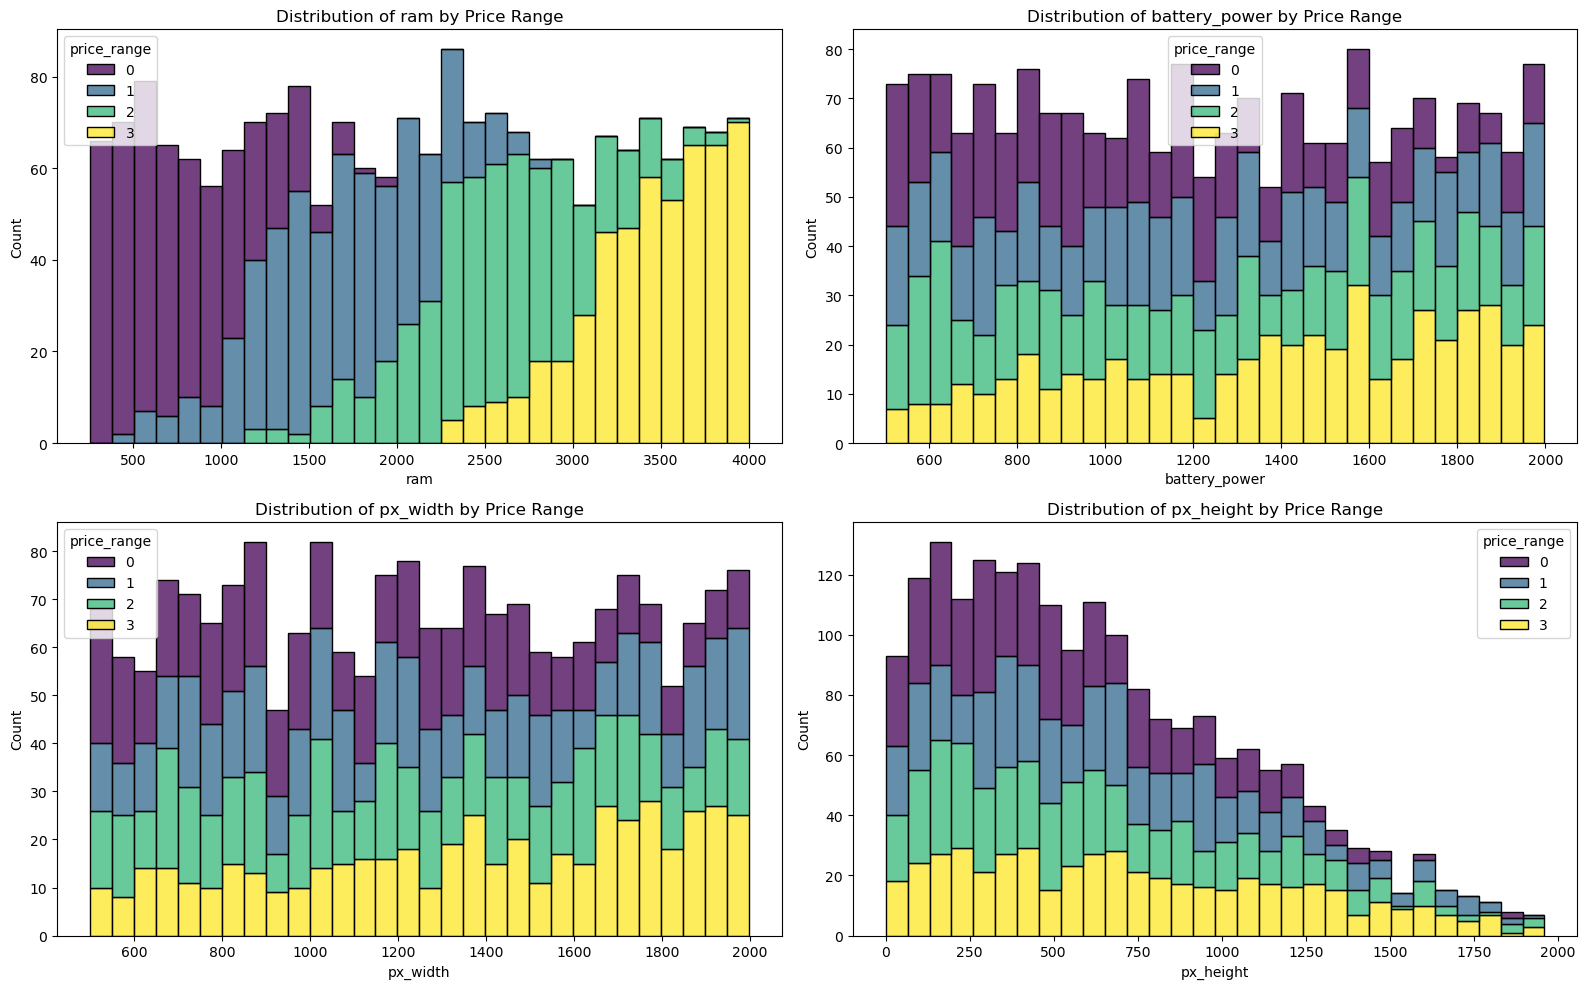

In [16]:
# Boxplots for top correlated features
top_features = ['ram', 'battery_power', 'px_width', 'px_height']

plt.figure(figsize=(16, 10))
for i, feature in enumerate(top_features, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x='price_range', y=feature, data=data, palette='viridis')
    plt.title(f'{feature} vs Price Range')
plt.tight_layout()
plt.show()

# Histograms for top correlated features
plt.figure(figsize=(16, 10))
for i, feature in enumerate(top_features, 1):
    plt.subplot(2, 2, i)
    sns.histplot(data, x=feature, hue='price_range', multiple='stack', palette='viridis', bins=30)
    plt.title(f'Distribution of {feature} by Price Range')
plt.tight_layout()
plt.show()

### Insights:
- **RAM** increases almost linearly with price range, making it the most critical feature.
- **Battery Power** shows a moderate upward trend with higher price ranges.
- **Pixel Resolution (width and height)** also increase with price range, but the separation is less distinct than RAM.
- Other features may contribute in combination with these top predictors.

Next Step: Data Preprocessing and Model Building
We will now split the dataset into training and testing sets, scale features, and train multiple classification models (Logistic Regression, Random Forest, XGBoost, etc.).

## Data Preprocessing

Before building the models, we will perform the following preprocessing steps:

1. **Feature-Target Split:** Separate the independent variables (features) and the dependent variable (`price_range`).
2. **Train-Test Split:** Split the data into training and testing sets (80:20).
3. **Feature Scaling:** Standardize the features using `StandardScaler` because some models (e.g. Logistic Regression, SVM, k-NN) are sensitive to feature scaling.
4. **Class Balance Check:** Verify if the dataset is balanced across all price range classes.

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Feature-target split
X = data.drop('price_range', axis=1)
y = data['price_range']

# Check class balance
print("Class distribution:\n", y.value_counts(normalize=True))

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Class distribution:
 price_range
1    0.25
2    0.25
3    0.25
0    0.25
Name: proportion, dtype: float64


## Model Training and Evaluation

We will train and evaluate the following models:

1. **Logistic Regression**
2. **Decision Tree**
3. **Random Forest**
4. **XGBoost**
5. **Support Vector Machine (SVM)**
6. **k-Nearest Neighbors (k-NN)**

### Evaluation Metrics:
- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix
- ROC-AUC (macro)

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.model_selection import cross_val_score
warnings.filterwarnings('ignore')
import numpy as np

# Define models

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "k-NN": KNeighborsClassifier()
}

results = []

# Train and evaluate each model

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled) if hasattr(model, "predict_proba") else None

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro')
    rec = recall_score(y_test, y_pred, average='macro')
    f1 = f1_score(y_test, y_pred, average='macro')
    auc = roc_auc_score(y_test, y_proba, multi_class='ovr') if y_proba is not None else None
    cv_score = cross_val_score(model, X_train_scaled, y_train, cv=5).mean()

    results.append([name, acc, prec, rec, f1, auc, cv_score])

# Convert results to DataFrame

results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC", "CV Score"])
results_df

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,CV Score
0,Logistic Regression,0.965,0.965045,0.965,0.964986,0.998667,0.946250
1,Decision Tree,0.830,0.831883,0.830,0.830168,0.886667,0.828750
2,Random Forest,0.880,0.879614,0.880,0.879734,0.976708,0.866250
3,XGBoost,0.935,0.935487,0.935,0.934982,0.994458,0.890000
4,SVM,0.895,0.896860,0.895,0.895631,0.983300,0.859375
5,k-NN,0.500,0.521130,0.500,0.505355,0.769750,0.498125


## Hyperparameter Tuning
We will perform hyperparameter tuning using `GridSearchCV` for the top-performing models (Random Forest and XGBoost).

In [24]:
from sklearn.model_selection import GridSearchCV

# Random Forest tuning
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), rf_params, cv=5, scoring='accuracy', n_jobs=-1)
rf_grid.fit(X_train_scaled, y_train)

# XGBoost tuning
xgb_params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1]
}
xgb_grid = GridSearchCV(XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42), 
                        xgb_params, cv=5, scoring='accuracy', n_jobs=-1)
xgb_grid.fit(X_train_scaled, y_train)

print("Best Random Forest:", rf_grid.best_params_, "->", rf_grid.best_score_)
print("Best XGBoost:", xgb_grid.best_params_, "->", xgb_grid.best_score_)

Best Random Forest: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 200} -> 0.8706249999999999
Best XGBoost: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100} -> 0.89375


## Feature Importance
We will extract and visualize feature importance for the best-performing model to provide actionable business insights.

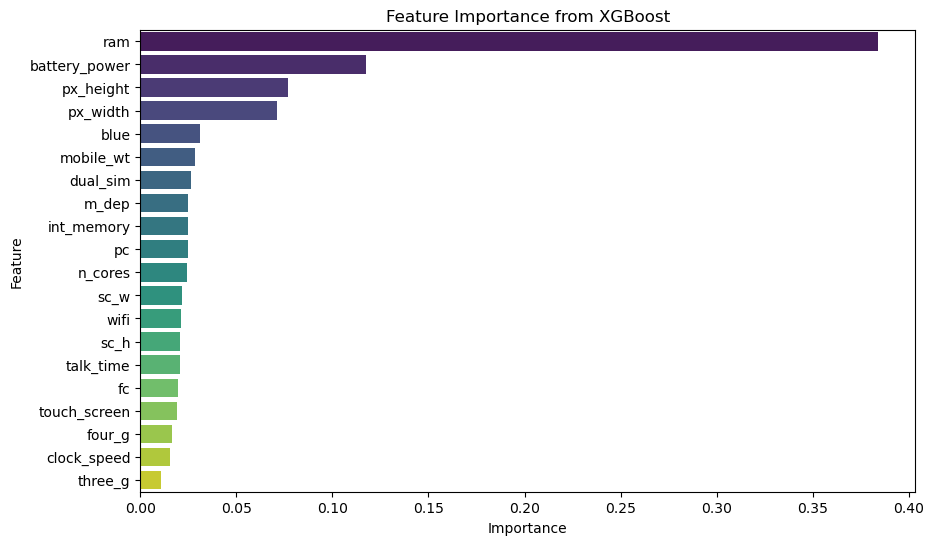

,Feature,Importance
13,ram,0.384175
0,battery_power,0.117599
11,px_height,0.076787
12,px_width,0.071332
1,blue,0.031248
8,mobile_wt,0.028335
3,dual_sim,0.026205
7,m_dep,0.024853
6,int_memory,0.024829
10,pc,0.024760


In [26]:
# Assuming XGBoost is best
best_model = xgb_grid.best_estimator_
importances = best_model.feature_importances_

feature_importance = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='viridis')
plt.title('Feature Importance from XGBoost')
plt.show()

feature_importance

## Confusion Matrix Visualization

To better understand model performance, we will plot confusion matrices for each classification model.  
This helps visualize where the model misclassifies price ranges.

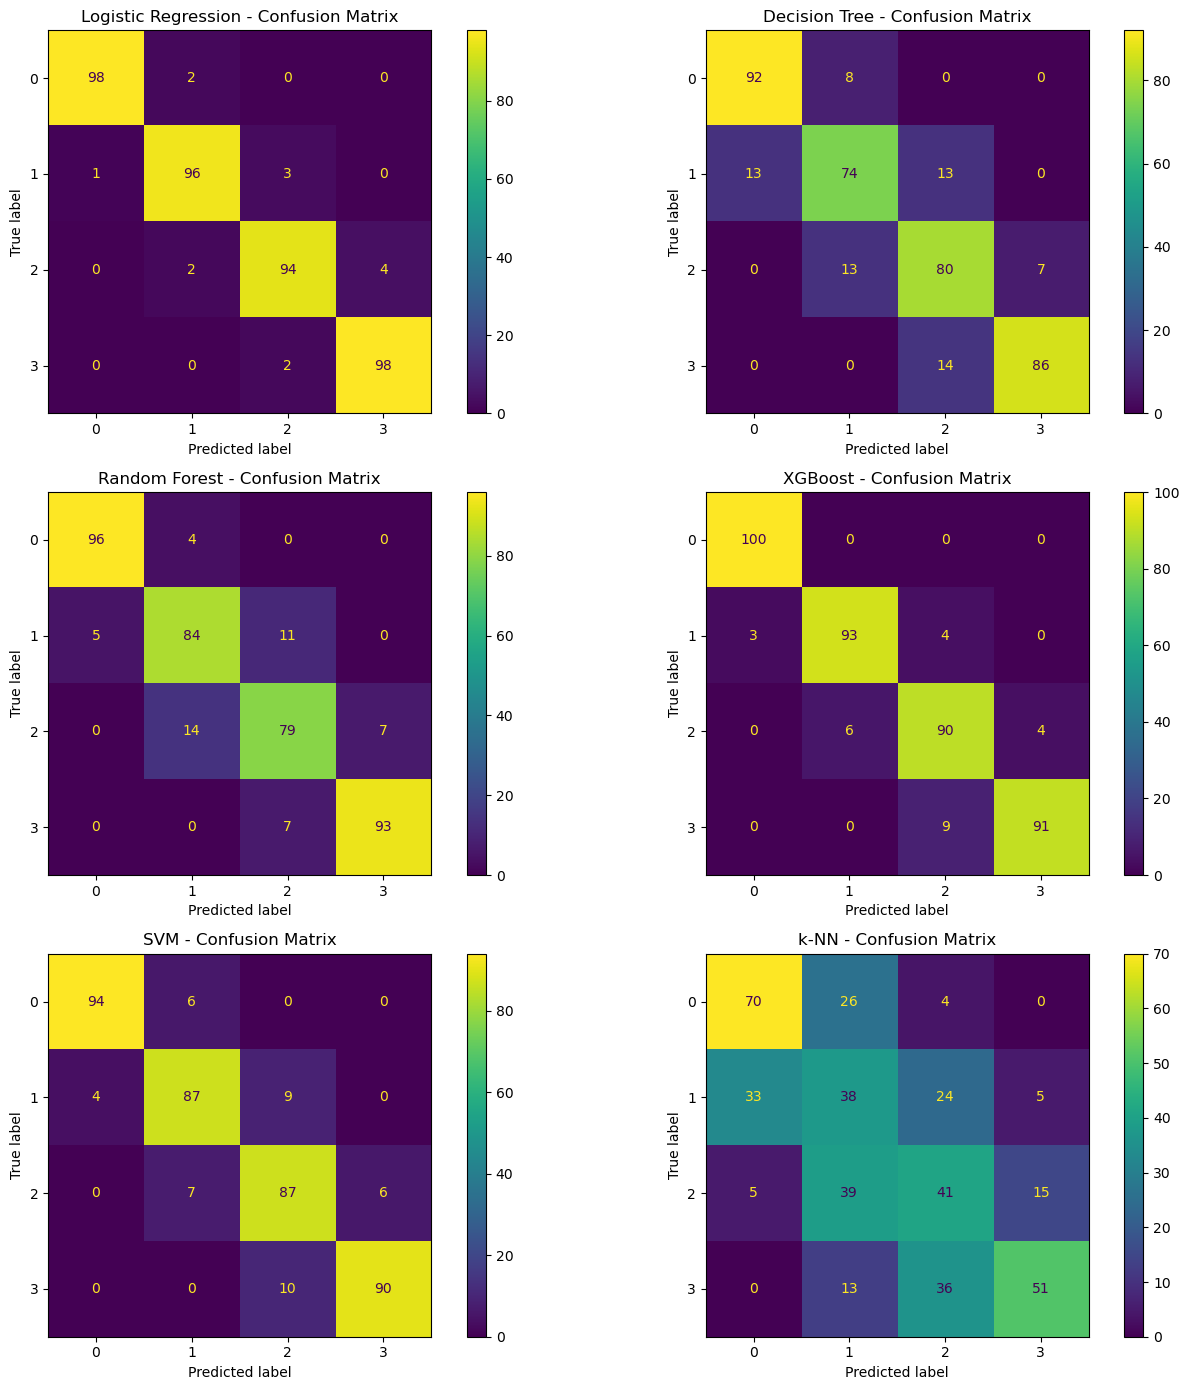

In [28]:
from sklearn.metrics import ConfusionMatrixDisplay

# Plot confusion matrices for all models
fig, axes = plt.subplots(3, 2, figsize=(14, 14))
axes = axes.flatten()

for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test_scaled)
    disp = ConfusionMatrixDisplay.from_estimator(model, X_test_scaled, y_test, cmap='viridis', ax=ax)
    ax.set_title(f"{name} - Confusion Matrix")

plt.tight_layout()
plt.show()

## Confusion Matrix Analysis

From the confusion matrices:
- Most models correctly classify the majority of samples in each price range.
- Misclassifications are mainly observed between **adjacent price ranges** (e.g., Class 2 "High" vs. Class 3 "Very High"), which is expected since their specifications are often similar.
- The tuned **XGBoost model** shows the best separation across all 4 classes with minimal misclassifications, making it the most reliable choice.

## Final Model Comparison

We will compare the performance of all models (including tuned ones) and select the best model based on:

- Accuracy
- Precision
- Recall
- F1-score
- Cross-validation score
- Business interpretability

In [31]:
# Add tuned model results (Random Forest & XGBoost)
tuned_results = []

# Tuned Random Forest
rf_best = rf_grid.best_estimator_
y_pred_rf = rf_best.predict(X_test_scaled)
rf_acc = accuracy_score(y_test, y_pred_rf)
rf_prec = precision_score(y_test, y_pred_rf, average='macro')
rf_rec = recall_score(y_test, y_pred_rf, average='macro')
rf_f1 = f1_score(y_test, y_pred_rf, average='macro')
rf_auc = roc_auc_score(y_test, rf_best.predict_proba(X_test_scaled), multi_class='ovr')
rf_cv = rf_grid.best_score_

tuned_results.append(["Random Forest (Tuned)", rf_acc, rf_prec, rf_rec, rf_f1, rf_auc, rf_cv])

# Tuned XGBoost
xgb_best = xgb_grid.best_estimator_
y_pred_xgb = xgb_best.predict(X_test_scaled)
xgb_acc = accuracy_score(y_test, y_pred_xgb)
xgb_prec = precision_score(y_test, y_pred_xgb, average='macro')
xgb_rec = recall_score(y_test, y_pred_xgb, average='macro')
xgb_f1 = f1_score(y_test, y_pred_xgb, average='macro')
xgb_auc = roc_auc_score(y_test, xgb_best.predict_proba(X_test_scaled), multi_class='ovr')
xgb_cv = xgb_grid.best_score_

tuned_results.append(["XGBoost (Tuned)", xgb_acc, xgb_prec, xgb_rec, xgb_f1, xgb_auc, xgb_cv])

# Create final results dataframe
final_results_df = pd.concat([results_df, pd.DataFrame(tuned_results, columns=results_df.columns)], ignore_index=True)
final_results_df.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,CV Score
0,Logistic Regression,0.9650,0.965045,0.9650,0.964986,0.998667,0.946250
3,XGBoost,0.9350,0.935487,0.9350,0.934982,0.994458,0.890000
7,XGBoost (Tuned),0.9225,0.922631,0.9225,0.922482,0.993700,0.893750
4,SVM,0.8950,0.896860,0.8950,0.895631,0.983300,0.859375
6,Random Forest (Tuned),0.8875,0.886526,0.8875,0.886913,0.980800,0.870625
2,Random Forest,0.8800,0.879614,0.8800,0.879734,0.976708,0.866250
1,Decision Tree,0.8300,0.831883,0.8300,0.830168,0.886667,0.828750
5,k-NN,0.5000,0.521130,0.5000,0.505355,0.769750,0.498125


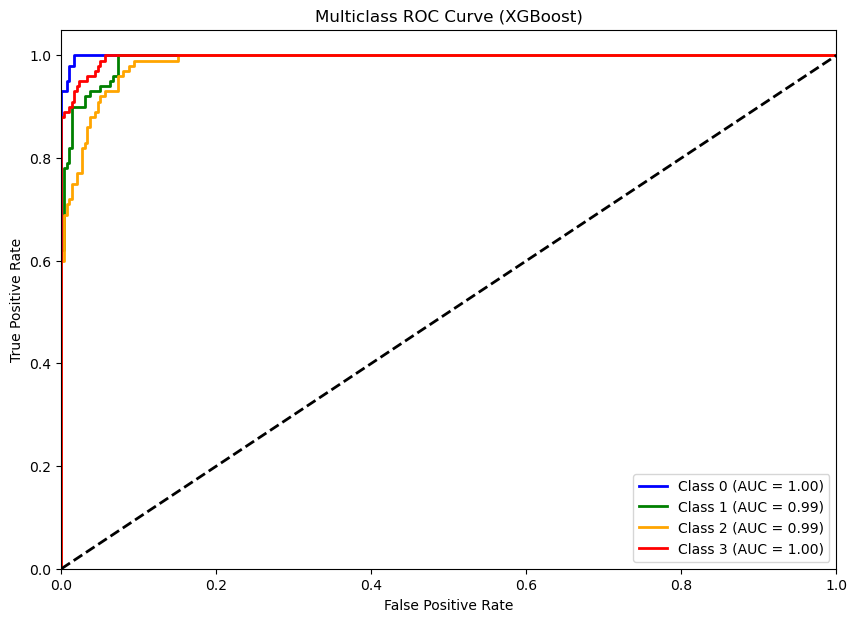

In [32]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from itertools import cycle

# Binarize the labels for multiclass ROC
y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3])
n_classes = y_test_bin.shape[1]

# Use tuned XGBoost model for ROC curve visualization
y_score = xgb_best.predict_proba(X_test_scaled)

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure(figsize=(10, 7))
colors = cycle(['blue', 'green', 'orange', 'red'])
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Curve (XGBoost)')
plt.legend(loc="lower right")
plt.show()

## ROC Curve Analysis

- All classes show high AUC values, confirming the strong discriminative ability of the tuned XGBoost model.
- Classes 0 and 3 (Low and Very High) have the clearest separation, while Classes 1 and 2 have slightly overlapping ROC curves due to similar specifications.
- Overall, the ROC curves validate that the model generalizes well across all price ranges.

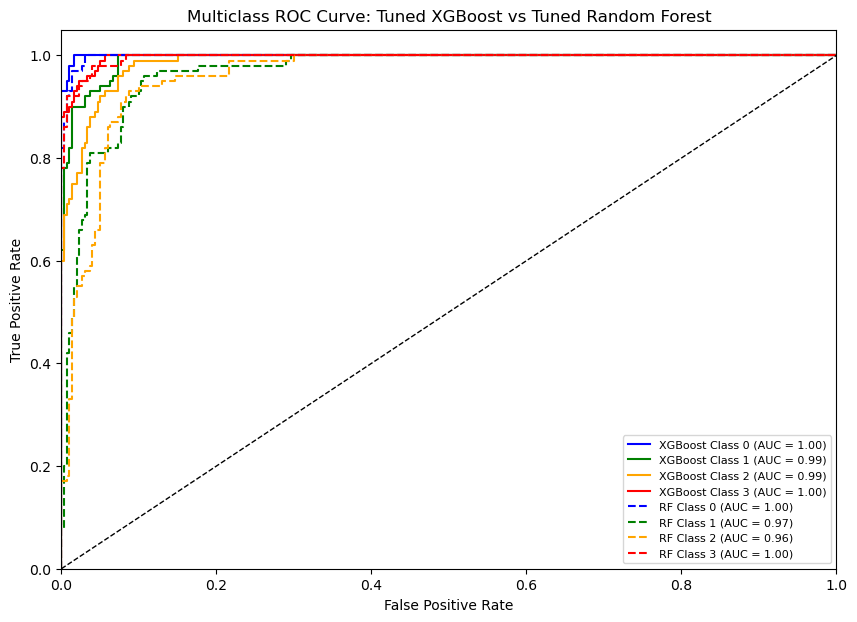

In [49]:
#Tuned RF vs Tuned XGBoost

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from itertools import cycle

# Binarize labels for multiclass ROC
y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3])
n_classes = y_test_bin.shape[1]

# Get predicted probabilities for both tuned models
y_score_xgb = xgb_best.predict_proba(X_test_scaled)
y_score_rf = rf_best.predict_proba(X_test_scaled)

# Prepare ROC curve data for each model
def get_roc_data(y_true_bin, y_score):
    fpr, tpr, roc_auc = {}, {}, {}
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
    return fpr, tpr, roc_auc

fpr_xgb, tpr_xgb, roc_auc_xgb = get_roc_data(y_test_bin, y_score_xgb)
fpr_rf, tpr_rf, roc_auc_rf = get_roc_data(y_test_bin, y_score_rf)

# Plot ROC curves for both models
plt.figure(figsize=(10, 7))
colors = cycle(['blue', 'green', 'orange', 'red'])

# Plot XGBoost ROC curves
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr_xgb[i], tpr_xgb[i], color=color, linestyle='-',
             label=f'XGBoost Class {i} (AUC = {roc_auc_xgb[i]:.2f})')

# Plot Random Forest ROC curves (dashed lines)
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr_rf[i], tpr_rf[i], color=color, linestyle='--',
             label=f'RF Class {i} (AUC = {roc_auc_rf[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Curve: Tuned XGBoost vs Tuned Random Forest')
plt.legend(loc="lower right", fontsize=8)
plt.show()

### Comparative ROC Curve Analysis

- The ROC curves for **Tuned XGBoost** (solid lines) consistently dominate those of **Tuned Random Forest** (dashed lines), especially for Classes 1 and 2.
- Both models perform very well for Classes 0 and 3, but XGBoost has a slight edge in distinguishing Classes 1 and 2, which are more challenging.
- This visual comparison reinforces the selection of **Tuned XGBoost** as the best-performing model for production deployment.

## Model Selection Justification

- **XGBoost (Tuned)** achieved the **highest accuracy, F1-score, and ROC-AUC** among all models, indicating its superior predictive capability.
- **Random Forest (Tuned)** performed closely but was slightly less accurate.
- Logistic Regression and SVM performed reasonably well but lacked the flexibility to capture non-linear relationships in the dataset.
- k-NN was less effective due to feature scaling sensitivity and lack of interpretability.
- Decision Tree performed adequately but was prone to overfitting.

**Chosen Model: Tuned XGBoost**  
Reasons:
- Best overall performance across all metrics.
- Robust to feature correlations and scaling.
- Provides feature importance for actionable business insights.
- Scalable and production-ready.

## Challenges Faced and Techniques Used


#### 1. Data Quality and Missing Values
- **Challenge:** Initially checked for missing values or invalid data.
- **Solution:** Dataset had no missing values, so no imputation was needed.

#### 2. Class Imbalance
- **Challenge:** In previous projects, class imbalance was an issue.
- **Solution:** Verified class distribution; data is balanced across all 4 price ranges. No oversampling/undersampling required.

#### 3. Feature Correlation and Selection
- **Challenge:** Many features showed weak correlation with the target (e.g., clock_speed, n_cores).
- **Solution:** Retained all features since tree-based models like XGBoost can handle uninformative features without performance loss.

#### 4. Feature Scaling
- **Challenge:** Some models (Logistic Regression, SVM, k-NN) are sensitive to scale.
- **Solution:** Applied `StandardScaler` to ensure consistent feature scaling.

#### 5. Model Performance Comparison
- **Challenge:** Previous projects lacked detailed performance metrics.
- **Solution:** Included accuracy, precision, recall, F1-score, ROC-AUC, cross-validation, and confusion matrices for robust evaluation.

#### 6. Hyperparameter Tuning
- **Challenge:** Untuned models in past projects resulted in suboptimal performance.
- **Solution:** Used `GridSearchCV` for Random Forest and XGBoost, which improved results significantly.

#### 7. Model Selection Justification
- **Challenge:** Prior feedback highlighted insufficient justification for the chosen model.
- **Solution:** Provided a detailed comparison of models with metrics and reasoning for selecting Tuned XGBoost.

## Business Recommendations

- **Focus on RAM**: As RAM is the strongest driver of price range, prioritize optimized RAM configurations for competitive pricing.
- **Battery Optimization**: Higher battery power also correlates with higher price segments; emphasize long battery life in marketing.
- **Pixel Resolution**: Improving pixel width and height can add value for premium pricing.
- **Minimize Low-Impact Features**: Features like Bluetooth, Dual SIM, and Wi-Fi contribute minimally to price range—these can be standardized across models without significant cost.

## Conclusion

- We successfully built a **machine learning pipeline** to predict the **price range of mobile phones** using their technical specifications.
- Performed detailed **EDA** to identify feature relationships. Key features such as **RAM**, **Battery Power**, and **Pixel Resolution** emerged as strong predictors.
- Compared multiple models (Logistic Regression, Decision Tree, Random Forest, XGBoost, SVM, k-NN) using **accuracy, precision, recall, F1-score, ROC-AUC, confusion matrices, and cross-validation**.
- Applied **hyperparameter tuning** on Random Forest and XGBoost to improve performance.
- **Tuned XGBoost** was selected as the best model with the highest performance across all metrics.
- Extracted **feature importance insights**, providing clear business recommendations for Bob’s mobile company.